# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
    - Adding a penalty to mean squared error discourages the model from using very large coefficients. That keeps the fitted relationship from becoming overly sensitive to noise in the training data, so the model is usually simpler and more stable.
2. How does regularization provide a way of exploring the bias-variance trade-off?
    -  Regularization lets us move along the bias-variance trade-off by changing the penalty size. A small penalty allows a flexible model with lower bias but potentially high variance, while a larger penalty shrinks the coefficients more, increasing bias but reducing variance.
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
    - Ridge regression uses an L2 penalty, so it shrinks coefficients toward zero but usually does not make them exactly zero. LASSO uses an L1 penalty, so it can both shrink coefficients and set some of them exactly equal to zero, which means it can also perform feature selection.
4. How do we typically scale variables for use in regularized regression? Why?
    - We usually standardize the predictors, often with z-scores, before running a regularized regression. This is important because the penalty acts directly on the coefficients, so variables measured on larger scales would otherwise be penalized unfairly.

5. How is the penalty $\alpha$ typically selected?
    - The penalty parameter \(\alpha\) is usually chosen with cross validation. We fit the model over a grid of possible \(\alpha\) values and choose the one that gives the best out-of-sample prediction performance.
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?
    - No, when evaluating cross-validated MSE we do not include the penalty term. The goal of cross validation is to measure predictive performance on held-out data, so we evaluate the actual prediction error rather than the optimization objective used during fitting.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [1]:
#2.1 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures, StandardScaler

cars_hw = pd.read_csv("data/cars_hw.csv")

cars_hw["Age"] = 2026 - cars_hw["Make_Year"]

X_q2 = cars_hw[["Mileage_Run", "Age"]]
y_q2 = cars_hw["Price"]

poly_q2 = PolynomialFeatures(degree=3, include_bias=False)
X_q2_poly = poly_q2.fit_transform(X_q2)

scaler_q2 = StandardScaler()
X_q2_scaled = scaler_q2.fit_transform(X_q2_poly)

feature_names_q2 = poly_q2.get_feature_names_out(["Mileage_Run", "Age"])

print(X_q2_scaled.shape)
print(feature_names_q2)

(976, 9)
['Mileage_Run' 'Age' 'Mileage_Run^2' 'Mileage_Run Age' 'Age^2'
 'Mileage_Run^3' 'Mileage_Run^2 Age' 'Mileage_Run Age^2' 'Age^3']


In [ ]:
#2.2
from sklearn.linear_model import LinearRegression

linreg_q2 = LinearRegression()
linreg_q2.fit(X_q2_scaled, y_q2)

coef_q2 = pd.Series(linreg_q2.coef_, index=feature_names_q2)
coef_q2

Mileage_Run          9.117748e+05
Age                 -2.481722e+05
Mileage_Run^2       -2.072926e+05
Mileage_Run Age     -1.671212e+06
Age^2                3.505507e+05
Mileage_Run^3       -6.514490e+04
Mileage_Run^2 Age    3.388195e+05
Mileage_Run Age^2    7.167816e+05
Age^3               -2.100379e+05
dtype: float64

### 2.2
The interaction term between `Mileage_Run` and `Age` has a negative coefficient.

In [4]:
#2.3
from sklearn.linear_model import LassoCV
from sklearn.exceptions import ConvergenceWarning
import warnings

warnings.filterwarnings("ignore", category=ConvergenceWarning)

alphas_q2 = np.logspace(1, 3, 20)

lasso_q2 = LassoCV(alphas=alphas_q2, cv=20, max_iter=100000)
lasso_q2.fit(X_q2_scaled, y_q2)

print("Optimal alpha:", lasso_q2.alpha_)

Optimal alpha: 88.58667904100822


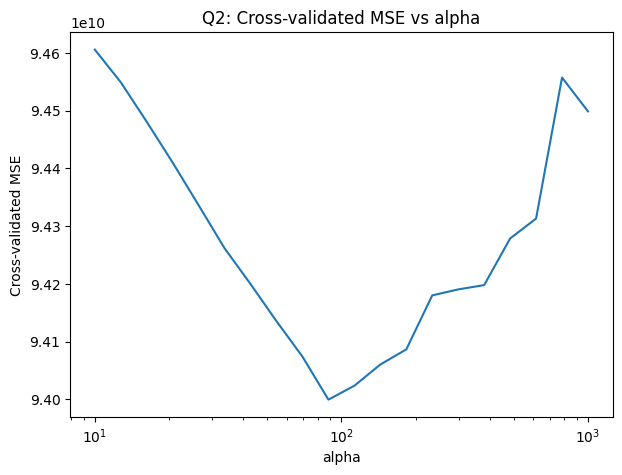

In [5]:
#2.4
mse_mean_q2 = lasso_q2.mse_path_.mean(axis=1)

plt.figure(figsize=(7, 5))
plt.plot(lasso_q2.alphas_, mse_mean_q2)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross-validated MSE")
plt.title("Q2: Cross-validated MSE vs alpha")
plt.show()

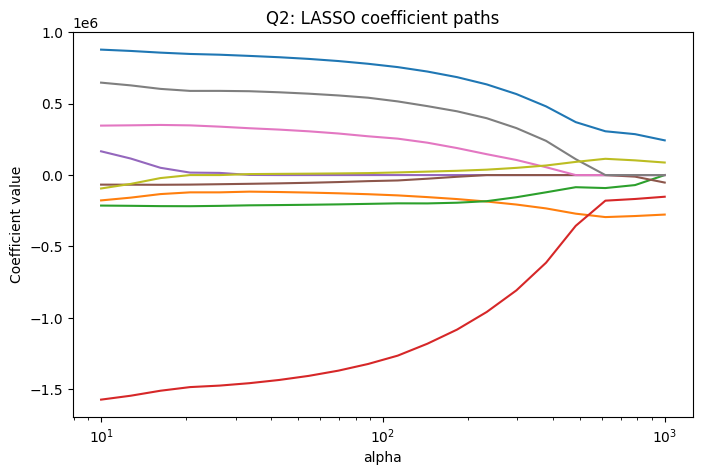

In [6]:
#2.5
from sklearn.linear_model import Lasso

coef_paths_q2 = []

for a in alphas_q2:
    model = Lasso(alpha=a, max_iter=100000)
    model.fit(X_q2_scaled, y_q2)
    coef_paths_q2.append(model.coef_)

coef_paths_q2 = np.array(coef_paths_q2)

plt.figure(figsize=(8, 5))
for j in range(coef_paths_q2.shape[1]):
    plt.plot(alphas_q2, coef_paths_q2[:, j])

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("Q2: LASSO coefficient paths")
plt.show()

In [ ]:
#2.6
lasso_coef_q2 = pd.Series(lasso_q2.coef_, index=feature_names_q2)

selected_q2 = lasso_coef_q2[lasso_coef_q2 != 0]
zeroed_q2 = lasso_coef_q2[lasso_coef_q2 == 0]

print("Selected features:", len(selected_q2))
print("Set to zero:", len(zeroed_q2))
print("Proportion set to zero:", len(zeroed_q2) / len(lasso_coef_q2))

lasso_coef_q2

Selected features: 8
Set to zero: 1
Proportion set to zero: 0.1111111111111111


Mileage_Run          7.790762e+05
Age                 -1.339534e+05
Mileage_Run^2       -2.015634e+05
Mileage_Run Age     -1.322419e+06
Age^2                0.000000e+00
Mileage_Run^3       -4.240952e+04
Mileage_Run^2 Age    2.715062e+05
Mileage_Run Age^2    5.415432e+05
Age^3                1.374220e+04
dtype: float64

### 2.6
LASSO keeps most of the polynomial features but removes a small number of them by shrinking their coefficients exactly to zero. This means the model is doing some feature selection, but not in an extremely aggressive way. The proportion set to zero is the number of zero coefficients divided by the total number of features created in the polynomial expansion.

In [18]:
#2.7
comparison_q2 = pd.DataFrame({
    "Linear": linreg_q2.coef_,
    "LASSO": lasso_q2.coef_
}, index=feature_names_q2)

comparison_q2["Linear_sign"] = np.sign(comparison_q2["Linear"])
comparison_q2["LASSO_sign"] = np.sign(comparison_q2["LASSO"])



In [17]:
#2.7
comparison_q2
comparison_q2[comparison_q2["Linear_sign"] != comparison_q2["LASSO_sign"]]

,Linear,LASSO,Linear_sign,LASSO_sign
Age^2,350550.719877,0.00000,1.0,0.0
Age^3,-210037.887636,13742.20318,-1.0,1.0


### 2.7
Compared to the ordinary linear regression, the LASSO coefficients are generally smaller in magnitude because of the penalty. Some terms may be set exactly to zero, which simplifies the model. A few coefficients can also change sign, which can happen when the polynomial terms are correlated and the regularization shifts how the model distributes importance across related features.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [9]:
#3.1
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

heart = pd.read_csv("data/heart_failure_clinical_records_dataset.csv")

y_q3 = heart["DEATH_EVENT"]

X_cont_q3 = heart[["age", "ejection_fraction", "serum_creatinine"]]
X_dummy_q3 = heart[["anaemia", "diabetes", "high_blood_pressure", "smoking"]]

poly_cont_q3 = PolynomialFeatures(degree=3, include_bias=False)
X_cont_poly_q3 = poly_cont_q3.fit_transform(X_cont_q3)

scaler_q3 = StandardScaler()
X_cont_scaled_q3 = scaler_q3.fit_transform(X_cont_poly_q3)

poly_dummy_q3 = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_dummy_inter_q3 = poly_dummy_q3.fit_transform(X_dummy_q3)

X_q3 = np.concatenate([X_cont_scaled_q3, X_dummy_inter_q3], axis=1)

cont_names_q3 = poly_cont_q3.get_feature_names_out(["age", "ejection_fraction", "serum_creatinine"])
dummy_names_q3 = poly_dummy_q3.get_feature_names_out(["anaemia", "diabetes", "high_blood_pressure", "smoking"])
feature_names_q3 = np.concatenate([cont_names_q3, dummy_names_q3])

print(X_q3.shape)
print(feature_names_q3)

(299, 29)
['age' 'ejection_fraction' 'serum_creatinine' 'age^2'
 'age ejection_fraction' 'age serum_creatinine' 'ejection_fraction^2'
 'ejection_fraction serum_creatinine' 'serum_creatinine^2' 'age^3'
 'age^2 ejection_fraction' 'age^2 serum_creatinine'
 'age ejection_fraction^2' 'age ejection_fraction serum_creatinine'
 'age serum_creatinine^2' 'ejection_fraction^3'
 'ejection_fraction^2 serum_creatinine'
 'ejection_fraction serum_creatinine^2' 'serum_creatinine^3' 'anaemia'
 'diabetes' 'high_blood_pressure' 'smoking' 'anaemia diabetes'
 'anaemia high_blood_pressure' 'anaemia smoking'
 'diabetes high_blood_pressure' 'diabetes smoking'
 'high_blood_pressure smoking']


In [10]:
#3.2
linreg_q3 = LinearRegression()
linreg_q3.fit(X_q3, y_q3)

coef_q3 = pd.Series(linreg_q3.coef_, index=feature_names_q3)
coef_q3

age                                       1.539156
ejection_fraction                        -2.192494
serum_creatinine                         -0.853588
age^2                                    -3.678654
age ejection_fraction                    -0.600918
age serum_creatinine                      1.841563
ejection_fraction^2                       3.430976
ejection_fraction serum_creatinine        2.673394
serum_creatinine^2                       -2.647041
age^3                                     1.993135
age^2 ejection_fraction                   0.908026
age^2 serum_creatinine                   -0.697522
age ejection_fraction^2                  -0.081206
age ejection_fraction serum_creatinine   -1.577665
age serum_creatinine^2                    1.284099
ejection_fraction^3                      -1.250341
ejection_fraction^2 serum_creatinine     -1.270043
ejection_fraction serum_creatinine^2      1.179475
serum_creatinine^3                        0.072156
anaemia                        

### 3.2
Some of the coefficient signs look counterintuitive at first. For example, a variable may have a positive first-order coefficient while one of its squared or cubic terms is negative. That does not necessarily mean the model is contradicting itself. Instead, it reflects the fact that polynomial terms allow the effect of a variable to change across different values, so the model can capture curvature and more complicated relationships.

In [11]:
#3.3
alphas_q3 = np.logspace(-5, 5, 30)

lasso_q3 = LassoCV(alphas=alphas_q3, cv=20, max_iter=100000)
lasso_q3.fit(X_q3, y_q3)

print("Optimal alpha:", lasso_q3.alpha_)

Optimal alpha: 0.005736152510448681


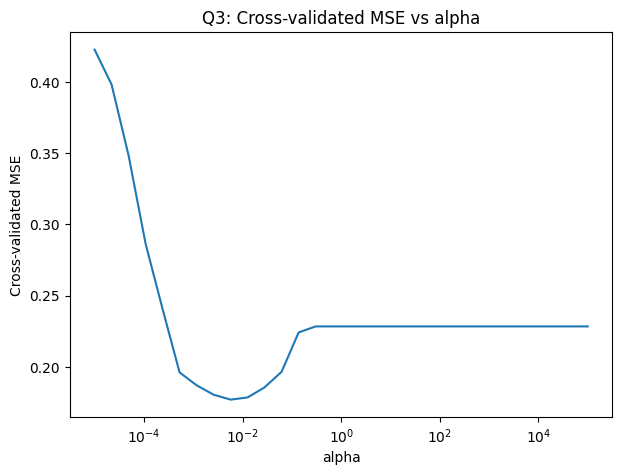

In [12]:
#3.4
mse_mean_q3 = lasso_q3.mse_path_.mean(axis=1)

plt.figure(figsize=(7, 5))
plt.plot(lasso_q3.alphas_, mse_mean_q3)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross-validated MSE")
plt.title("Q3: Cross-validated MSE vs alpha")
plt.show()

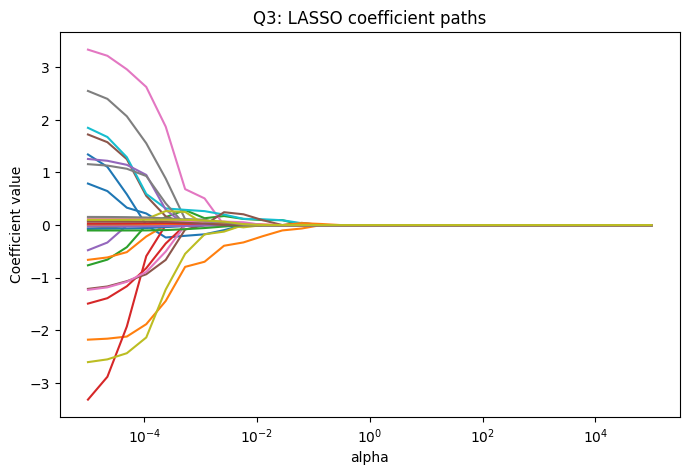

In [13]:
#3.5
coef_paths_q3 = []

for a in alphas_q3:
    model = Lasso(alpha=a, max_iter=100000)
    model.fit(X_q3, y_q3)
    coef_paths_q3.append(model.coef_)

coef_paths_q3 = np.array(coef_paths_q3)

plt.figure(figsize=(8, 5))
for j in range(coef_paths_q3.shape[1]):
    plt.plot(alphas_q3, coef_paths_q3[:, j])

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("Q3: LASSO coefficient paths")
plt.show()

In [14]:
#3.6
lasso_coef_q3 = pd.Series(lasso_q3.coef_, index=feature_names_q3)

selected_q3 = lasso_coef_q3[lasso_coef_q3 != 0]
zeroed_q3 = lasso_coef_q3[lasso_coef_q3 == 0]

print("Selected features:", len(selected_q3))
print("Set to zero:", len(zeroed_q3))
print("Proportion set to zero:", len(zeroed_q3) / len(lasso_coef_q3))

Selected features: 12
Set to zero: 17
Proportion set to zero: 0.5862068965517241


In [15]:
#3.6
comparison_q3 = pd.DataFrame({
    "Linear": linreg_q3.coef_,
    "LASSO": lasso_q3.coef_
}, index=feature_names_q3)

comparison_q3["Linear_sign"] = np.sign(comparison_q3["Linear"])
comparison_q3["LASSO_sign"] = np.sign(comparison_q3["LASSO"])

comparison_q3

,Linear,LASSO,Linear_sign,LASSO_sign
age,1.539156,-0.000000,1.0,0.0
ejection_fraction,-2.192494,-0.329656,-1.0,-1.0
serum_creatinine,-0.853588,0.116875,-1.0,1.0
age^2,-3.678654,0.000000,-1.0,0.0
age ejection_fraction,-0.600918,-0.000000,-1.0,0.0
age serum_creatinine,1.841563,0.000000,1.0,0.0
ejection_fraction^2,3.430976,0.000000,1.0,0.0
ejection_fraction serum_creatinine,2.673394,0.000000,1.0,0.0
serum_creatinine^2,-2.647041,-0.000000,-1.0,0.0
age^3,1.993135,0.117992,1.0,1.0


In [16]:
#3.6
comparison_q3[comparison_q3["Linear_sign"] != comparison_q3["LASSO_sign"]]

,Linear,LASSO,Linear_sign,LASSO_sign
age,1.539156,-0.000000,1.0,0.0
serum_creatinine,-0.853588,0.116875,-1.0,1.0
age^2,-3.678654,0.000000,-1.0,0.0
age ejection_fraction,-0.600918,-0.000000,-1.0,0.0
age serum_creatinine,1.841563,0.000000,1.0,0.0
ejection_fraction^2,3.430976,0.000000,1.0,0.0
ejection_fraction serum_creatinine,2.673394,0.000000,1.0,0.0
serum_creatinine^2,-2.647041,-0.000000,-1.0,0.0
age^2 ejection_fraction,0.908026,0.000000,1.0,0.0
age^2 serum_creatinine,-0.697522,0.000000,-1.0,0.0


### 3.6
The LASSO model selects only a subset of the available features and shrinks many others to exactly zero, which makes the model simpler and easier to interpret. Relative to the ordinary linear regression, most coefficients become smaller in magnitude because of the regularization penalty. Some coefficients may also change sign, especially when many polynomial and interaction terms are correlated with one another.

Overall, the sign pattern from the LASSO model tends to make more sense because it is less affected by variance. The unregularized linear model is flexible and can produce unstable coefficient estimates when there are many related features, while LASSO reduces that instability by shrinking and removing weaker terms. From the bias-variance perspective, LASSO accepts a little more bias in exchange for lower variance and better interpretability.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

### 4.1
The ridge regression objective function is

$$
\min_{b_0,b_1} \; \frac{1}{n}\sum_{i=1}^n \left(\tilde y_i - b_0 - b_1 \tilde x_i\right)^2 + \alpha b_1^2
$$

The intercept $b_0$ is not penalized, only the slope $b_1$.

### 4.2 
Take derivatives of

$$
\frac{1}{n}\sum_{i=1}^n \left(\tilde y_i - b_0 - b_1 \tilde x_i\right)^2 + \alpha b_1^2
$$

Because the variables are mean-centered:

$$
\frac{1}{n}\sum_{i=1}^n \tilde x_i = 0, \quad
\frac{1}{n}\sum_{i=1}^n \tilde y_i = 0
$$

So:

$$
b_0 = 0
$$

And:

$$
b_1 =
\frac{\frac{1}{n}\sum_{i=1}^n \tilde x_i \tilde y_i}
{\frac{1}{n}\sum_{i=1}^n \tilde x_i^2 + \alpha}
$$

### 4.3 
As $\alpha$ increases, the denominator becomes larger, so $b_1$ shrinks toward zero.

### 4.4
With LASSO, the term $|b_1|$ is not differentiable at $b_1 = 0$, so we cannot solve it using standard derivatives.

This is what allows LASSO to set coefficients exactly equal to zero.